# Data Analysis

In [2]:
import pandas as pd

# Load data into pandas DataFrames
path = 'quality_assured_csv/'
brands = pd.read_csv(path+'brands_qu.csv')
orderlines = pd.read_csv(path+'orderlines_qu.csv')
orders = pd.read_csv(path+'orders_qu.csv')
products = pd.read_csv(path+'products_qu.csv')

path2 = 'original_csv/'
brands_orig = pd.read_csv(path2+'brands.csv')
orderlines_orig = pd.read_csv(path2+'orderlines.csv')
orders_orig = pd.read_csv(path2+'orders.csv')
products_orig = pd.read_csv(path2+'products.csv')

Load our cleaned DataFrames

In [3]:
# create copies of the original data
orders_df = orders.copy()
orderlines_df = orderlines.copy()
brands_df = brands.copy()
products_df = products.copy()

In [4]:
# convert date columns to datetime
orders_df['created_date'] = pd.to_datetime(orders_df['created_date'])
orderlines_df['date'] = pd.to_datetime(orderlines_df['date'])

Answer simple questions

In [5]:
# What is the time period that the dataset covers?

orders_df['created_date'].min(), orders_df['created_date'].max()

(Timestamp('2017-01-01 01:51:47'), Timestamp('2018-03-14 12:03:52'))

In [6]:
# What is the overall revenue for that time?
orderlines_df['unit_price_total'].sum()

np.float64(7817204.399999999)

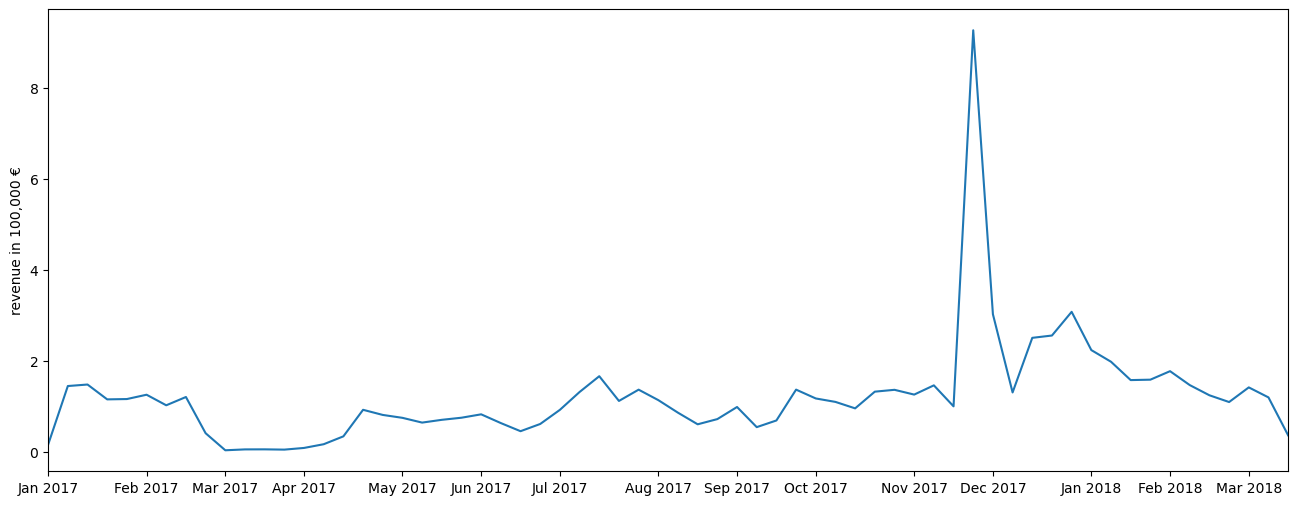

In [7]:
# Are there seasonal patterns in the evolution of revenue?
weekly_revenue = (orderlines_df.resample('W', on='date')['unit_price_total'].sum() / 100_000)
ax = weekly_revenue.plot(figsize=(16, 6),
                         ylabel='revenue in 100,000 €',
                         xlabel='')

monthly_ticks = weekly_revenue.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b %Y') for d in monthly_ticks])

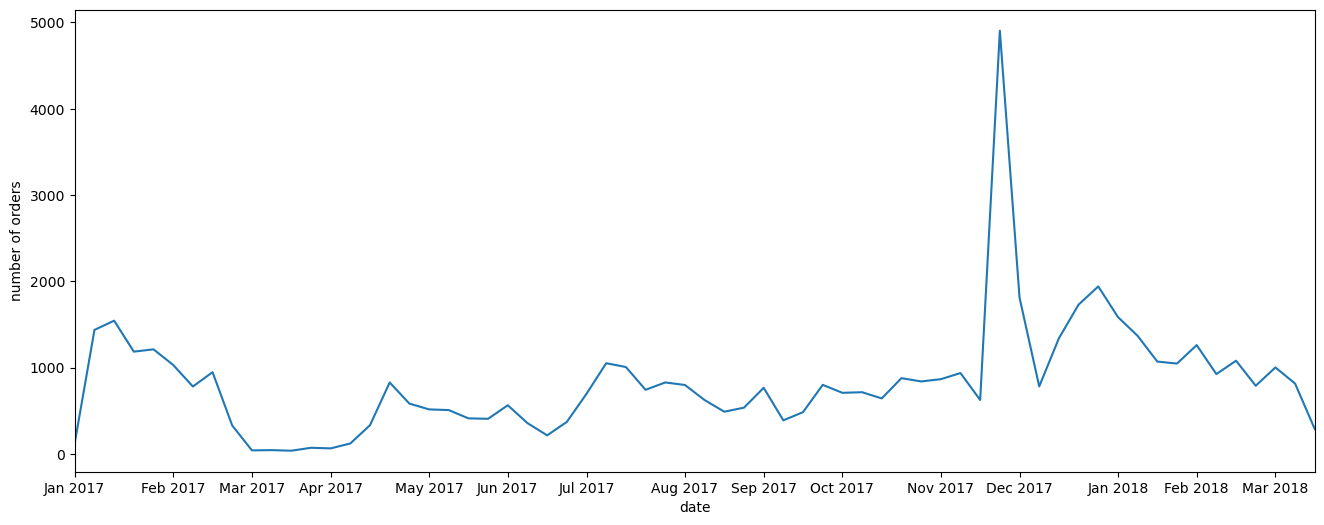

In [8]:
# Are there seasonal patterns in the evolution of sales?

weekly_sales = (orderlines_df.resample('W', on='date')['id_order'].count())
ax = weekly_sales.plot(figsize=(16, 6),
                         ylabel='number of orders')

monthly_ticks = weekly_sales.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b %Y') for d in monthly_ticks])

In [9]:
# What are the most sold products?
merge = orderlines_df.merge(products_df, how='left')

merge.groupby('sku', as_index=False).agg(
    sku_count=('sku', 'count'),
    name=('name', 'first'),
    desc=('desc', 'first')
    ).sort_values(by='sku_count', ascending=False).head(20)


,sku,sku_count,name,desc
448,APP1190,867,IPhone AppleCare Protection Plan,Apple Care extended warranty iPhone.
655,APP1922,511,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...
360,APP0698,478,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...
378,APP0927,378,EarPods Apple Headphones with Remote and Mic (...,EarPods headphones Apple iPhone iPad and iPod ...
3922,SAM0074,298,Samsung 850 EVO SSD Disk 500GB,SSD hard drive Mac and PC 25 inch 500GB SATA I...
4906,WDT0183,289,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4T...
1226,CRU0051,269,Crucial MX300 525GB SSD Disk,SSD 525GB SATA Hard Disk 3.0 (6Gb / s) for Mac...
765,APP2446,260,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray
665,APP1970,220,Apple iPhone 32GB Space Gray,New iPhone SE with 4-inch screen 32 free GB.
459,APP1214,207,Apple Magic Mouse 2,Bluetooth Apple Wireless Mouse


In [10]:
# What are the products that generate the most revenue?
merge = orderlines_df.merge(products_df, how='left')

merge.groupby('sku', as_index=False).agg(
    sku_count=('sku', 'count'),
    revenue = ('unit_price_total', 'sum'),
    name=('name', 'first'),
    desc=('desc', 'first')
    ).sort_values(by='revenue', ascending=False).head(20)


,sku,sku_count,revenue,name,desc
2372,LGE0044,201,135375.83,"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",99% Professional Monitor sRGB color calibrator...
765,APP2446,260,104560.64,Apple iPhone 6 32GB Space Gray,New iPhone 6 32GB Space Gray
655,APP1922,511,86473.26,AirPods Apple Bluetooth Headset for iPhone iPa...,Apple AirPods wireless headsets and cargo tran...
782,APP2477,102,85301.93,Apple iPhone 64GB Space Gray 8,Apple iPhone 64GB 8 Color Space Gray
665,APP1970,220,80715.76,Apple iPhone 32GB Space Gray,New iPhone SE with 4-inch screen 32 free GB.
707,APP2072,76,74964.06,"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM ...",laptop MacBook Air 13 inch i5 18GHz 8GB RAM an...
791,APP2485,78,70721.79,Apple iPhone 8 Plus 64GB Gold,Apple iPhone 8 Plus 64GB Gold color
4906,WDT0183,289,65589.96,"Red 4TB WD 35 ""Mac PC hard drive and NAS",Western Digital hard drive designed for NAS 4T...
789,APP2483,62,60090.08,Apple iPhone 8 Plus 64GB Space Gray,Apple iPhone 8 Plus 64GB Space Gray
784,APP2479,66,52981.19,Apple iPhone 64GB Gold 8,Apple iPhone 64GB 8 in Gold


## Discount analysis

In [11]:
#brand cleanup
# Fix KEN and MUJ (OTR and STA are complicated, so I am not touching them)
brands_df.loc[70,'long'] = 'Kensington'
brands_df.loc[98,'long'] = 'Mujjo'

# remove rows 19, 37, 80
brands_df = brands_df.drop([19,37,80])

In [72]:
#prepare products_df to include brands

# Add brand names to products_orderline_merge
# create brand_short column from sku in products
products_df.loc[:,'brand_short'] = products_df['sku'].str[:3]

# merge products and brands dataframes
products_brand_merge = products_df.merge(brands_df, how = 'left', left_on='brand_short', right_on = 'short')

In [13]:
# Add long brand names to products
products_df = products_brand_merge
products_df = products_df.drop(columns=['brand_short'])

In [14]:
# merge products with orderlines to create one big dataframe
products_orderline_merge = orderlines_df.merge(products_df, on='sku', how='left')

# create a discount and percentage discount column
products_orderline_merge.loc[:,'discount'] = round(products_orderline_merge['price']-products_orderline_merge['unit_price'])
products_orderline_merge.loc[:,'discount_percentage'] = round((products_orderline_merge['discount']/products_orderline_merge['price'])*100)

# create a total discount column
products_orderline_merge.loc[:,'total_discount'] = (products_orderline_merge['discount'] * products_orderline_merge['product_quantity'])



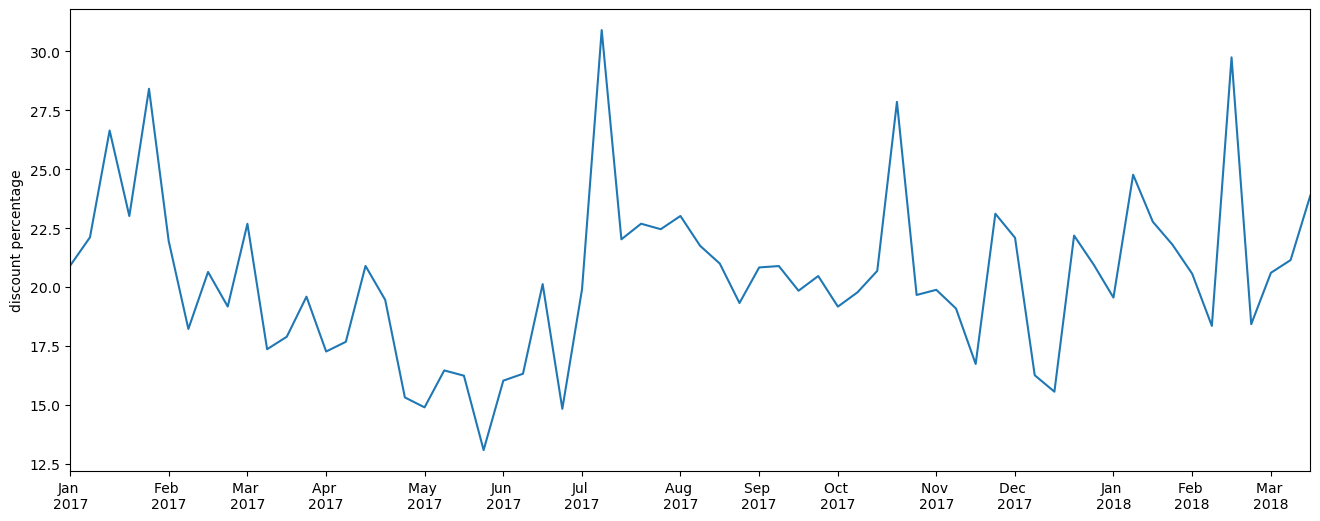

In [15]:
weekly_discount_percentage = (products_orderline_merge.resample('W', on='date')['discount_percentage'].mean())
ax = weekly_discount_percentage.plot(figsize=(16, 6),
                         ylabel='discount percentage',
                         xlabel='')

monthly_ticks = weekly_discount_percentage.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b \n%Y') for d in monthly_ticks])

Text(0.5, 1.0, 'Weekly Discount vs Weekly Revenue')

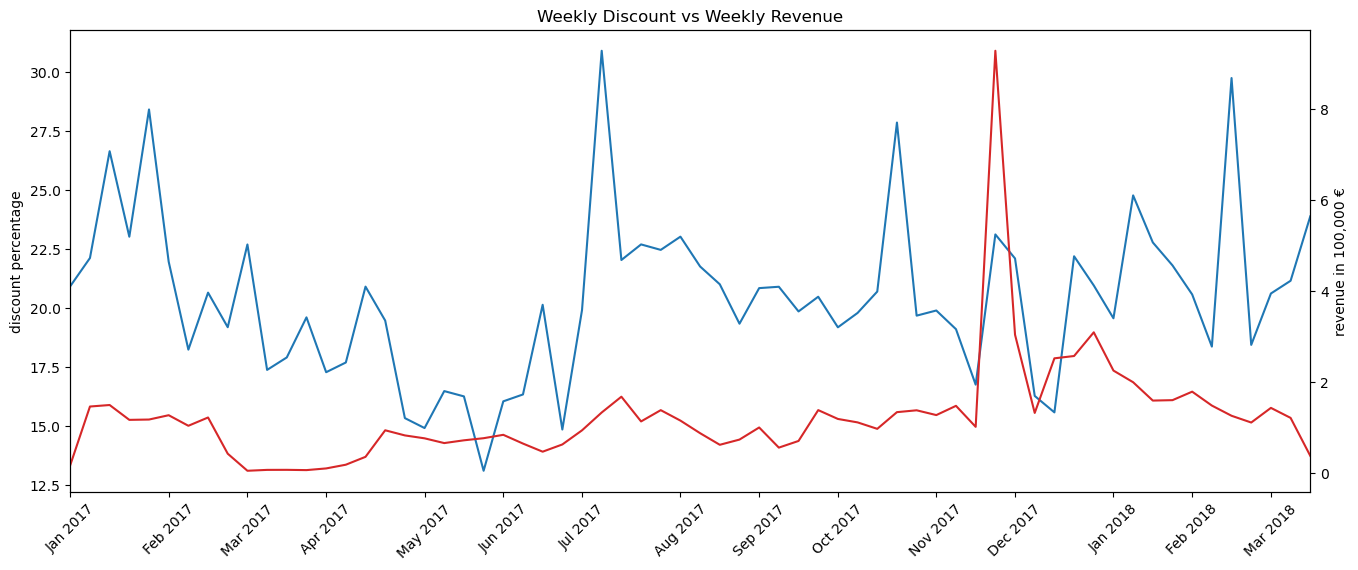

In [16]:
# plot weekly discount and weekly revenue in same graph
ax = weekly_discount_percentage.plot(
    figsize=(16, 6),
    ylabel='discount percentage',
    xlabel='',
    color='tab:blue'   # first color
)

ax2 = ax.twinx()

weekly_revenue.plot(
    ax=ax2,
    ylabel='revenue in 100,000 €',
    color='tab:red'    # second color
)

monthly_ticks = weekly_discount_percentage.resample('MS').first().index
ax.set_xticks(monthly_ticks)
ax.set_xticklabels([d.strftime('%b %Y') for d in monthly_ticks], rotation=45)
ax.set_title('Weekly Discount vs Weekly Revenue')


In [71]:
# create discount categories: (none: 0-1%, low: 1-9%, medium: 9-18%, high: 18-29%, very_high: 29-100%)
products_orderline_merge.loc[:,'discount_category'] = pd.cut(
    products_orderline_merge['discount_percentage'],
    bins=[0, 1, 9, 18, 29, 100],
    labels=['none', 'low', 'medium', 'high', 'very_high']
)

<Axes: xlabel='discount_category', ylabel='revenue in mio €'>

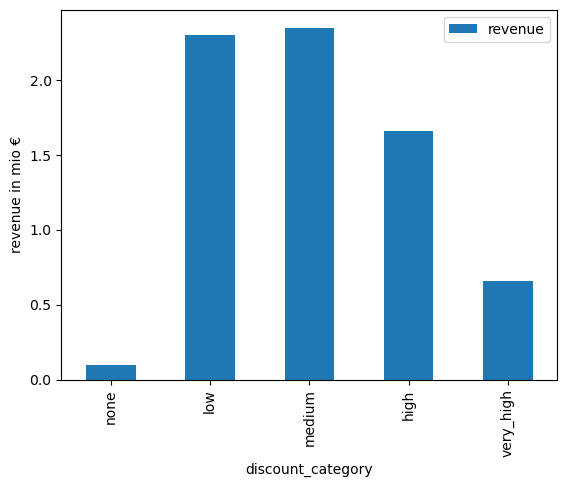

In [ ]:
# revenue by discount category (none: 0-1%, low: 1-9%, medium: 9-18%, high: 18-29%, very_high: 29-100%)
revenue_by_discount = products_orderline_merge.groupby('discount_category').agg(revenue=('unit_price_total', 'sum')) / 1_000_000

revenue_by_discount.plot(kind='bar',
                         ylabel='revenue in mio €')



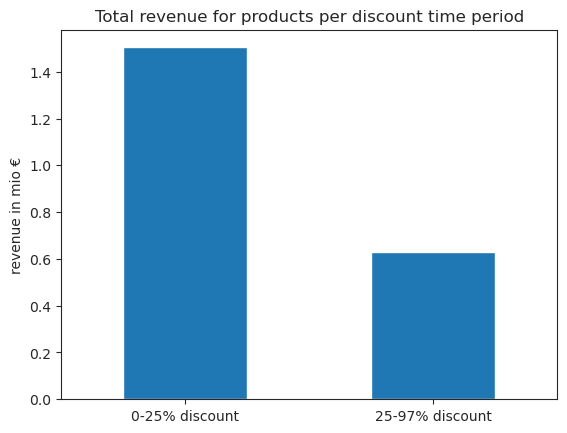

In [70]:
# Plot how much revenue the same product generates if there is low discount vs. high discount
# 844 products have data during low discount (0-25%) periods and high discount (25-97%) periods

import matplotlib.pyplot as plt

products_orderline_merge.loc[:,'discount_category_binary'] = pd.cut(
    products_orderline_merge['discount_percentage'],
    bins=[0, 25, 97],
    labels=['none_low', 'medium_high']
)

# create df containing low discount revenue
# create df containing high discount revenue

low_mask = products_orderline_merge['discount_category_binary'] == 'none_low'
high_mask = products_orderline_merge['discount_category_binary'] == 'medium_high'
low_discount_df = products_orderline_merge.loc[low_mask]
high_discount_df = products_orderline_merge.loc[high_mask]

# Group by sku (product) and calculate revenue
low_discount_by_sku_df = low_discount_df.groupby('sku', as_index=False).agg(revenue_low_discount=('unit_price_total', 'sum'))
high_discount_by_sku_df = high_discount_df.groupby('sku', as_index=False).agg(revenue_high_discount=('unit_price_total', 'sum'))

merged_discount = low_discount_by_sku_df.merge(high_discount_by_sku_df, on='sku', how='inner')

(merged_discount[['revenue_low_discount', 'revenue_high_discount']].sum().rename(index={'revenue_low_discount': r'0-25% discount',
                                                                                        'revenue_high_discount': r'25-97% discount'})/1_000_000).plot(
                                                                                            kind='bar',
                                                                                            ylabel='revenue in mio €',
                                                                                            title='Total revenue for products per discount time period',
                                                                                            rot=0)

plt.savefig("plots/product_revenue_by_time_period.png", bbox_inches="tight")

# Category creation

In [21]:
pd.set_option('display.max_rows', 1000)
pd.set_option("display.max_colwidth", 100)

In [ ]:
# create categories by searching with regular expression patterns in the 'name' and'desc' of the products.
# In addition filter with specific price cut-offs to exclude accessories
import re

def categorize_product(row):
    name = str(row['name']).lower()
    desc = str(row['desc']).lower()
    text = name + ' ' + desc
    price = float(row['price'])


    # 1. iPhones
    if re.search(r'iphone', name) and price > 300:
        return "iPhone"
    # 2. laptop_desktop_tablet
    if re.search(r'ipad', name) and price > 250:
        return "laptop_desktop_tablet"
    # 2. laptop_desktop_tablet
    if re.search(r'macbook', name) and price > 700:
        return "laptop_desktop_tablet"
    # 2. laptop_desktop_tablet
    if re.search(r'imac|mac mini|mac pro', name) and price > 400:
        return "laptop_desktop_tablet"
    # 3. servers
    if re.search(r'synology|qnap|rackstation', name):
        return "servers"
    if re.search(r'\bnas\b', name) and price > 200:
        return "servers"
    # 4. storage
    if re.search(r'raid|thunderbay|pegasus|g.?speed|my passport|my book'
                 r'|g.?drive|lacie|seagate backup|external.{0,20}(drive|disk)', text):
        return "storage"
    if re.search(r'\bssd\b|\bhdd\b|hard drive|solid state', name) and \
       not re.search(r'case|enclosure|repair|kit', name):
        return "storage"
    if re.search(r'\bdimm\b|so-dimm|ddr[234]|mac memory|owc memory|fcm memory'
                 r'|crucial.{0,10}memory|kingston.{0,10}memory|\d+gb.{0,10}ddr', name):
        return "storage"
    # 4. monitors 
    if re.search(r'\bmonitor\b|benq|\bdell\b.{0,20}\d+["\']|lg\s+\d+[a-z]|eizo', name):
        return "monitor"
    # 5. audio 
    if re.search(r'speaker|headphone|headset|earphone|earbud|microphone'
                 r'|bose|beats|jabra|jbl|soundlink|soundtouch', text):
        return "audio"
    # 6. Phone accessories (iPhone/iPod related, low price) 
    if re.search(r'iphone|ipod|lightning', text) and price < 300:
        return "phone_accessory"
    # 7. Computer accessories (Mac/iPad related, low price) 
    if re.search(r'ipad|macbook|imac|mac mini|mac pro|\bmac\b', text) and price < 700:
        if re.search(r'case|cover|sleeve|stand|hub|adapter|cable|charger|keyboard|dock', text):
            return "computer accessory"
        
    # 8. Fallback 
    return "other"

products_orderline_merge['category'] = products_orderline_merge.apply(categorize_product, axis=1)

In [25]:
products_orderline_merge.loc[(products_orderline_merge['price']/products_orderline_merge['unit_price']>3) & (products_orderline_merge['price']>1000)].groupby('sku', as_index=False).agg(
    order_count=('sku', 'count'),
    revenue = ('unit_price_total', 'sum'),
    name=('name', 'first'),
    desc=('desc', 'first'),
    brand=('long', 'first'),
    cat = ('category', 'first'),
    discount_percentage = ('discount_percentage', 'mean')
    ).sort_values(by='discount_percentage', ascending=False).head(20)

,sku,order_count,revenue,name,desc,brand,cat,discount_percentage
14,PAC2281,1,255.59,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,Pack,laptop_desktop_tablet,83.0
15,PAC2282,1,240.26,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,Pack,laptop_desktop_tablet,80.0
12,PAC2196,2,511.18,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,Pack,laptop_desktop_tablet,79.0
10,PAC2194,4,1042.36,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,Pack,laptop_desktop_tablet,78.5
5,PAC2062,1,335.59,"Second hand - Apple iMac 20 ""Core 2 Duo 266GHz | 4GB RAM | 250GB HDD",IMac used 20 inch Core 2 Duo 266GHz | 4GB RAM | 250GB HDD,Pack,laptop_desktop_tablet,78.0
11,PAC2195,1,265.60,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,Pack,laptop_desktop_tablet,78.0
6,PAC2063,3,1017.00,"Second hand - Apple iMac 20 ""Core 2 Duo 266GHz | 4GB RAM | 250GB HDD |",Refurbished iMac 20 inch Core 2 Duo 266GHz | 4GB RAM | 250GB HDD,Pack,laptop_desktop_tablet,77.0
2,PAC2057,1,349.00,"Second hand - Apple iMac 20 ""Core 2 Duo 24GHz | 4GB RAM | 250GB HDD",Refurbished iMac 20 inch Core 2 Duo 24GHz | 4GB RAM | 250GB HDD,Pack,laptop_desktop_tablet,77.0
13,PAC2198,6,1653.54,"Second hand - Apple iMac 20 ""Core 2 Duo 226GHz | 2GB RAM | 160GB HDD",Refurbished iMac 20 inch Core 2 Duo | 2GB RAM | 160GB HDD,Pack,laptop_desktop_tablet,77.0
1,PAC1921,1,318.99,"Second hand - Apple iMac 20 ""Core 2 Duo 24GHz | 3GB RAM | 250GB HDD | Early 2008",IMac used 20 inch Core 2 Duo 24GHz | 3GB RAM | 250GB HDD | Early 2008 (MB323LL / A),Pack,laptop_desktop_tablet,73.0


In [26]:
# What are the categories that generate the most revenue?

products_orderline_merge.groupby(['category'], as_index=False).agg(
    sku_unique_count=('sku', 'nunique'),
    revenue = ('unit_price_total', 'sum'),
    discount_percentage_average = ('discount_percentage', 'mean')
    ).round(1).sort_values(by='revenue', ascending=False).head(20)

,category,sku_unique_count,revenue,discount_percentage_average
8,storage,657,1678132.4,15.1
5,other,1194,1406570.5,21.4
2,iPhone,164,1335857.4,9.3
3,laptop_desktop_tablet,182,685898.3,12.9
4,monitor,165,672355.8,19.9
7,servers,268,635749.4,10.5
6,phone_accessory,1462,592072.7,26.4
0,audio,258,414526.5,26.0
1,computer accessory,748,396041.4,26.1


In [27]:
# What are the categories that offer the highest discounts on average?
products_orderline_merge.groupby(['category'], as_index=False).agg(
    sku_unique_count=('sku', 'nunique'),
    discount_percentage_average = ('discount_percentage', 'mean'),
    
    ).sort_values(by='discount_percentage_average', ascending=False).head(20)

,category,sku_unique_count,discount_percentage_average
6,phone_accessory,1462,26.371651
1,computer accessory,748,26.123532
0,audio,258,26.000000
5,other,1194,21.434613
4,monitor,165,19.878049
8,storage,657,15.141569
3,laptop_desktop_tablet,182,12.918638
7,servers,268,10.489796
2,iPhone,164,9.274879


In [28]:
# What are the top performing products or brands etc. 
# in terms of revenue (unit_price_total), order count,
# or sales volume (in general and over time)?

products_orderline_merge.groupby(['long'], as_index=False).agg(
    sku_unique_count=('sku', 'nunique'),
    sales_count = ('id_order', 'nunique'),
    sales_volume = ('product_quantity', 'sum'),
    discount_percentage_average = ('discount_percentage', 'mean'),
    revenue = ('unit_price_total', 'sum')
    ).round(0).sort_values(by='revenue', ascending=False).head(10)

,long,sku_unique_count,sales_count,sales_volume,discount_percentage_average,revenue
5,Apple,792,8892,11156,16.0,2580058.0
108,Pack,331,1582,1710,26.0,463774.0
101,OWC,258,3195,3857,22.0,456318.0
68,LaCie,99,1928,2130,11.0,454137.0
163,Western Digital,115,1677,2404,18.0,365381.0
66,LG,61,694,780,10.0,328724.0
162,Wacom,104,1590,1816,20.0,276070.0
19,Crucial,48,1588,2070,14.0,274924.0
24,Dell,40,604,746,17.0,265148.0
146,Synology,53,510,553,3.0,171065.0


In [29]:
# Brands with the highest discount percentage

products_orderline_merge.groupby(['long'], as_index=False).agg(
    sku_unique_count=('sku', 'nunique'),
    sales_count = ('id_order', 'nunique'),
    sales_volume = ('product_quantity', 'sum'),
    discount_percentage_average = ('discount_percentage', 'mean'),
    discount_average = ('discount', 'mean'),
    revenue = ('unit_price_total', 'sum')
    ).round(0).sort_values(by='discount_average', ascending=False).head(10)

,long,sku_unique_count,sales_count,sales_volume,discount_percentage_average,discount_average,revenue
29,Eizo,9,25,28,18.0,160.0,18172.0
110,Pebble,4,44,44,56.0,141.0,4891.0
23,DJI,2,49,50,31.0,107.0,12590.0
55,Jawbone,4,154,210,74.0,105.0,7572.0
28,Drobo,7,40,40,18.0,104.0,19694.0
114,Pqi,1,1,1,64.0,90.0,50.0
108,Pack,331,1582,1710,26.0,88.0,463774.0
95,Ninebot,6,60,62,15.0,85.0,28783.0
24,Dell,40,604,746,17.0,79.0,265148.0
138,Sonos,14,156,260,13.0,75.0,81974.0


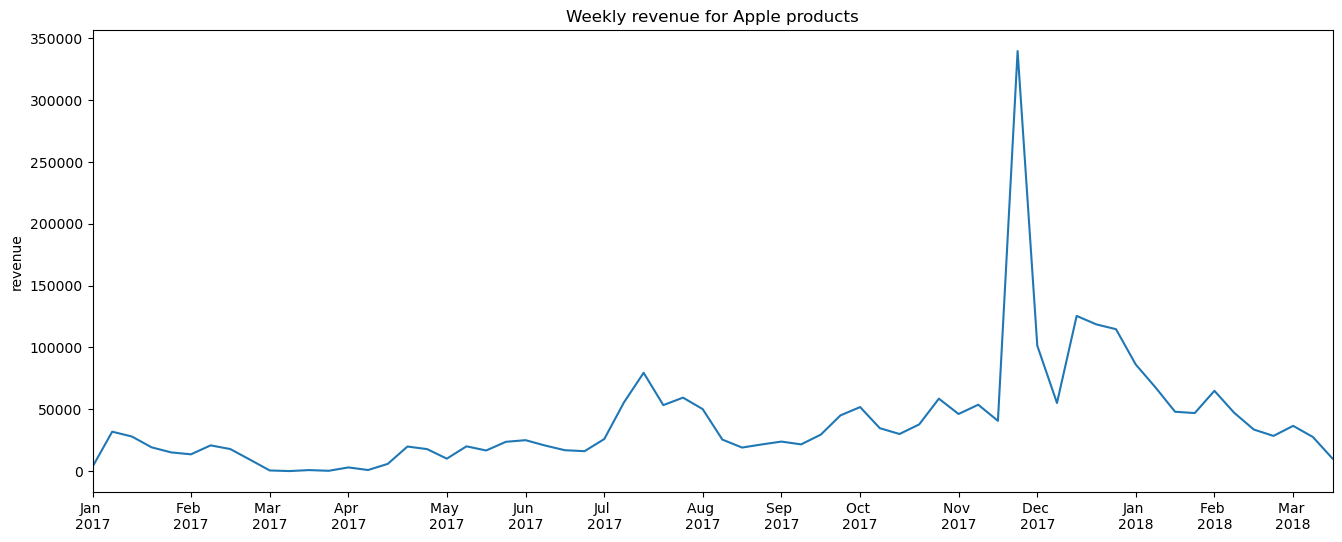

In [30]:
# apple revenue over time
apple_filter = products_orderline_merge['long'] == 'Apple'

ax = products_orderline_merge.loc[apple_filter].resample('W', on='date')['unit_price_total'].sum().plot(
    figsize=(16, 6),
    ylabel='revenue',
    xlabel='',
    title= 'Weekly revenue for Apple products'
)

monthly_ticks = weekly_discount_percentage.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b \n%Y') for d in monthly_ticks])

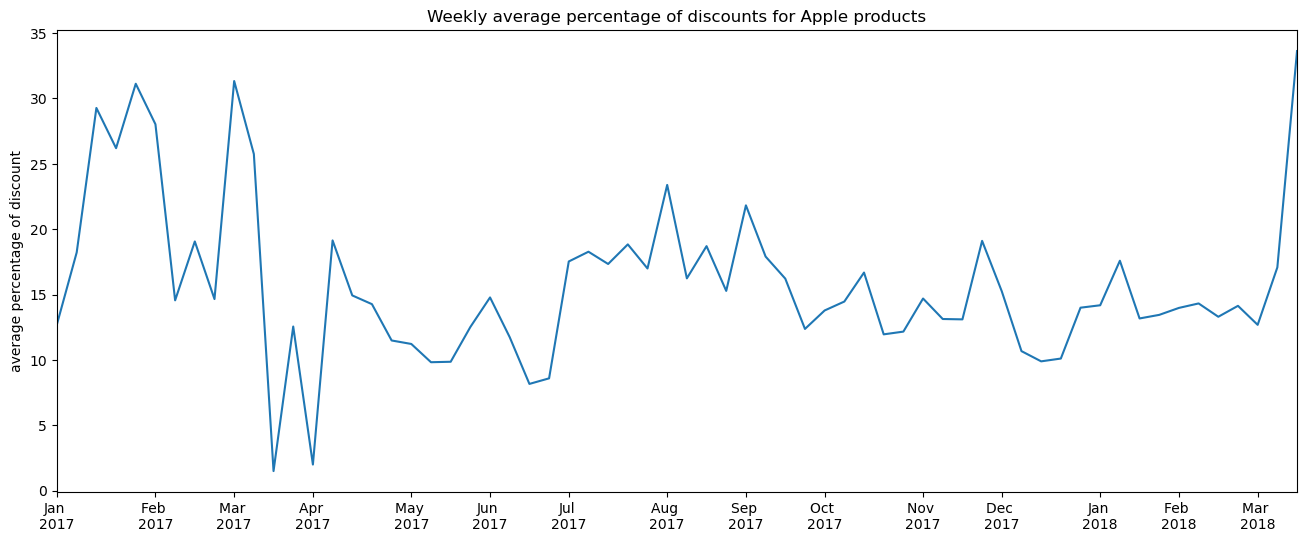

In [31]:
# apple discounts over time
apple_filter = products_orderline_merge['long'] == 'Apple'

ax = products_orderline_merge.loc[apple_filter].resample('W', on='date')['discount_percentage'].mean().plot(
    figsize=(16, 6),
    ylabel='average percentage of discount',
    xlabel='',
    title= 'Weekly average percentage of discounts for Apple products'
)

monthly_ticks = weekly_discount_percentage.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b \n%Y') for d in monthly_ticks])

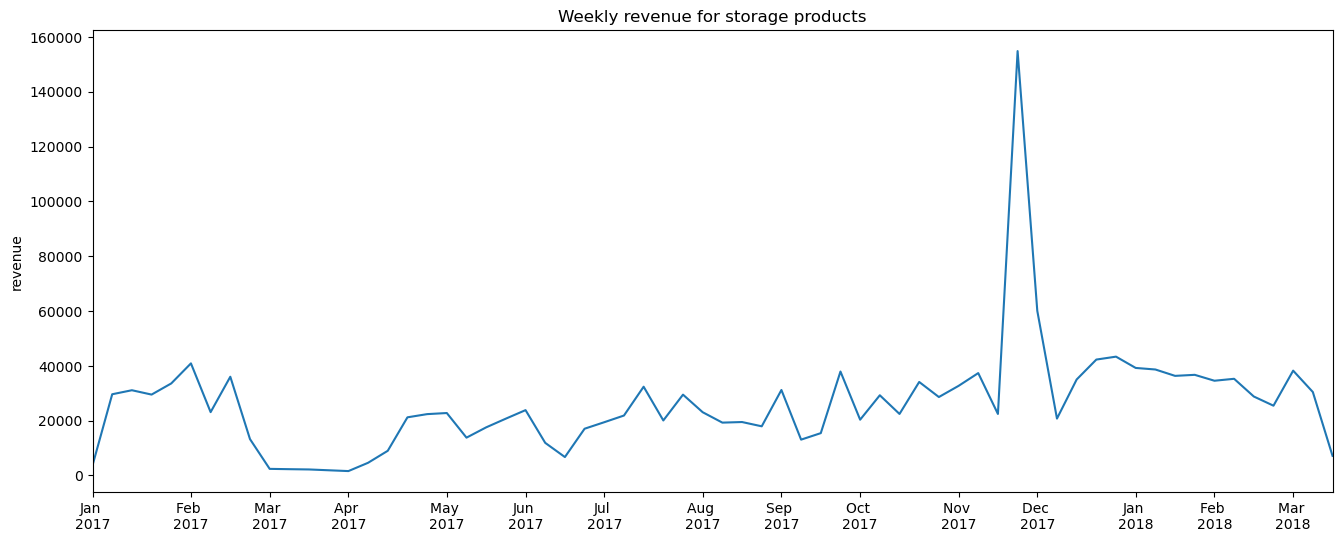

In [32]:
# storage revenue over time
storage_filter = products_orderline_merge['category'] == 'storage'

ax = products_orderline_merge.loc[storage_filter].resample('W', on='date')['unit_price_total'].sum().plot(
    figsize=(16, 6),
    ylabel='revenue',
    xlabel='',
    title= 'Weekly revenue for storage products'
)

monthly_ticks = weekly_discount_percentage.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b \n%Y') for d in monthly_ticks])

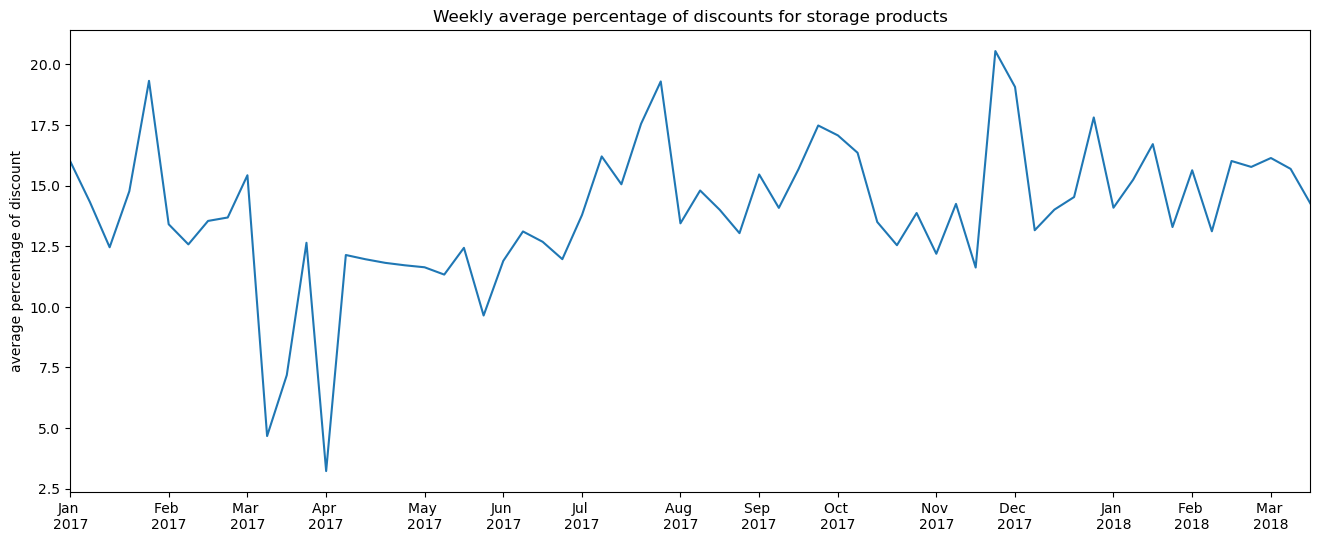

In [33]:
# storage discounts over time
storage_filter = products_orderline_merge['category'] == 'storage'

ax = products_orderline_merge.loc[storage_filter].resample('W', on='date')['discount_percentage'].mean().plot(
    figsize=(16, 6),
    ylabel='average percentage of discount',
    xlabel='',
    title= 'Weekly average percentage of discounts for storage products'
)

monthly_ticks = weekly_discount_percentage.resample('MS').first().index
ax.set_xticks(monthly_ticks)
_ = ax.set_xticklabels([d.strftime('%b \n%Y') for d in monthly_ticks])

<Axes: title={'center': 'Quarterly revenue by category'}, xlabel='Quarter', ylabel='revenue'>

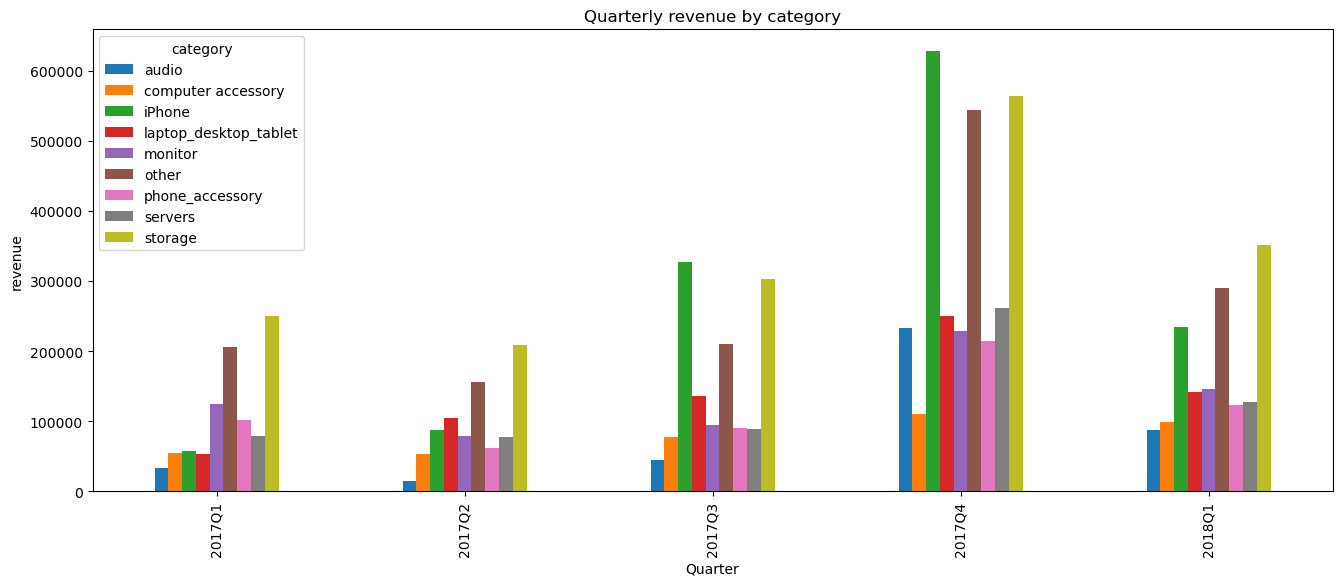

In [34]:
df_plot = (
    products_orderline_merge
    .groupby('category')
    .resample('QE', on='date')
    .agg(revenue=('unit_price_total', 'sum'))
    .reset_index()
    .pivot(index='date', columns='category', values='revenue')
)

# 🔑 fix here
df_plot.index = df_plot.index.to_period('Q').astype(str)

df_plot.plot(
    kind='bar',
    figsize=(16, 6),
    ylabel='revenue',
    xlabel='Quarter',
    title='Quarterly revenue by category'
)


# Explanatory graphs

### The Relationship between products.price and orderlines.unit_price

In [36]:
# create new column is_discounted
products_orderline_merge.loc[:,'is_discounted'] = products_orderline_merge['price'] > products_orderline_merge['unit_price']

products_orderline_merge.groupby(['sku'], as_index=False).agg(
    unit_price = ('unit_price', 'mean'),
    price = ('price', 'mean'),
    brand = ('long', 'first'),
    category = ('category', 'first'),
    is_discounted = ('is_discounted', 'median')
    ).round(0)['is_discounted'].value_counts()

is_discounted
1.0    4716
0.0     382
Name: count, dtype: int64

In [37]:
products_orderline_merge['is_discounted'].value_counts()

is_discounted
True     49404
False     3827
Name: count, dtype: int64

In [ ]:
# units sold at a discount of under 25 % and over 0 %
mask = products_orderline_merge['discount_percentage'] < 25
products_orderline_merge.loc[mask,'is_discounted'].value_counts()

is_discounted
True     31861
False     3827
Name: count, dtype: int64

In [41]:
# all units
products_orderline_merge['id'].count()

np.int64(53231)

In [42]:
# Percentage of products sold at 0 < discount < 25
31861/53231*100

59.854220285172175

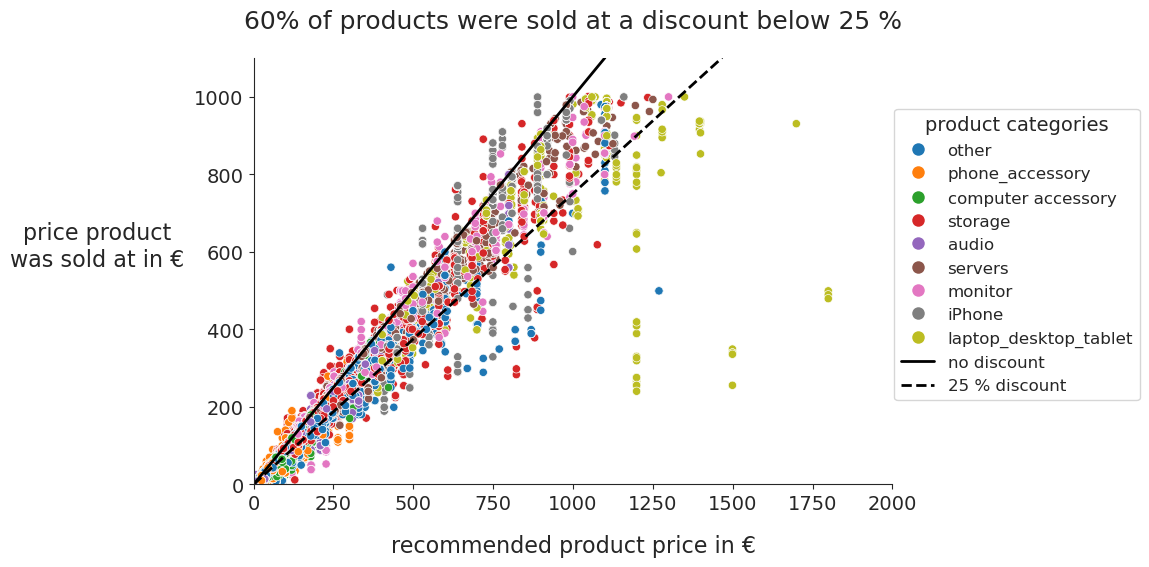

In [63]:
# plot showing discounting trend with product recommended price and sale price
import seaborn as sns

sns.set_style("ticks")

# Plot
price_rel_plot = sns.relplot(
    data=products_orderline_merge,
    x='price',
    y='unit_price',
    hue='category',
    aspect=1.5
)

# set axis limits 
price_rel_plot.set(xlim=(0, 2000), ylim=(0, 1100))

# change the xlabel sizes
price_rel_plot.ax.tick_params(axis='x', labelsize=14,)
# change the ylabel sizes and rotate label
price_rel_plot.ax.tick_params(axis='y', labelsize=14)

# 
price_rel_plot.ax.set_title(
    r"60% of products were sold at a discount below 25 %",
    fontsize=18,
    y=1.05
)
price_rel_plot.ax.set_xlabel(
    "recommended product price in €",
    fontsize=16,
    labelpad=15,
)

price_rel_plot.ax.set_ylabel(
    "price product\nwas sold at in €",
    fontsize=16,
    rotation=0,
    labelpad=70
)

# Remove the auto-generated seaborn legend
price_rel_plot.legend.remove()


# Add a line that shows discounted or not
price_rel_plot.ax.axline(
    (0, 0),  
    slope=1,
    color='black',
    linestyle='-',
    linewidth=2,
    label='no discount' 
)

# Add a line that shows 25 % discount
price_rel_plot.ax.axline(
    (0, 0),  
    slope=0.75,
    color='black',
    linestyle='--',
    linewidth=2,
    label=r'25 % discount' 
)

# change legend
price_rel_plot.ax.legend(
    title="product categories",
    title_fontsize=14,
    fontsize=12,  
    markerscale=1.5,
    loc='upper right',
    bbox_to_anchor=(1.4, 0.9)
)

price_rel_plot.savefig("plots/discount_trends_with_categories.png")

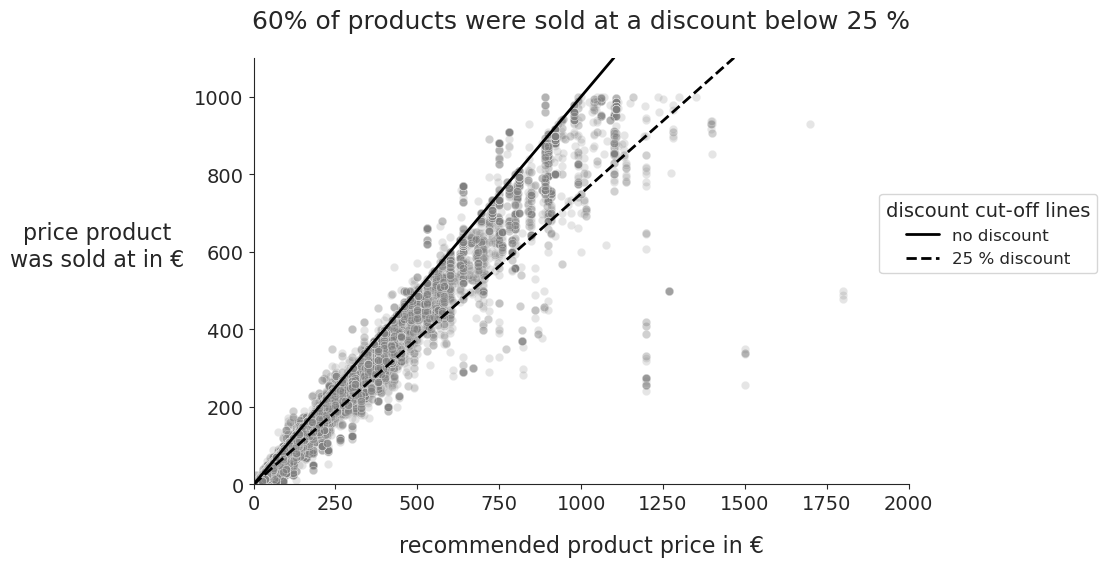

In [61]:
# Final plot showing 60 % of products were sold at a discount below 25 %
sns.set_style("ticks")

# Plot
price_rel_plot = sns.relplot(
    data=products_orderline_merge,
    x='price',
    y='unit_price',
    color = 'grey',
    aspect=1.5,
    alpha=0.2
)

# set axis limits 
price_rel_plot.set(xlim=(0, 2000), ylim=(0, 1100))

# change the xlabel sizes
price_rel_plot.ax.tick_params(axis='x', labelsize=14,)
# change the ylabel sizes
price_rel_plot.ax.tick_params(axis='y', labelsize=14)

# set title
price_rel_plot.ax.set_title(
    r"60% of products were sold at a discount below 25 %",
    fontsize=18,
    y=1.05
)
# set x labels
price_rel_plot.ax.set_xlabel(
    "recommended product price in €",
    fontsize=16,
    labelpad=15,
)
# set y labels
price_rel_plot.ax.set_ylabel(
    "price product\nwas sold at in €",
    fontsize=16,
    rotation=0,
    labelpad=70
)
# Add a line that shows discounted or not
price_rel_plot.ax.axline(
    (0, 0),  
    slope=1,
    color='black',
    linestyle='-',
    linewidth=2,
    label='no discount' 
)
# Add a line that shows 25 % discount
price_rel_plot.ax.axline(
    (0, 0),  
    slope=0.75,
    color='black',
    linestyle='--',
    linewidth=2,
    label=r'25 % discount' 
)
# change legend
price_rel_plot.ax.legend(
    title="discount cut-off lines",
    title_fontsize=14,
    fontsize=12,  
    markerscale=1.5,
    loc='upper right',
    bbox_to_anchor=(1.3, 0.7)
)

price_rel_plot.savefig("plots/discount_trends.png")

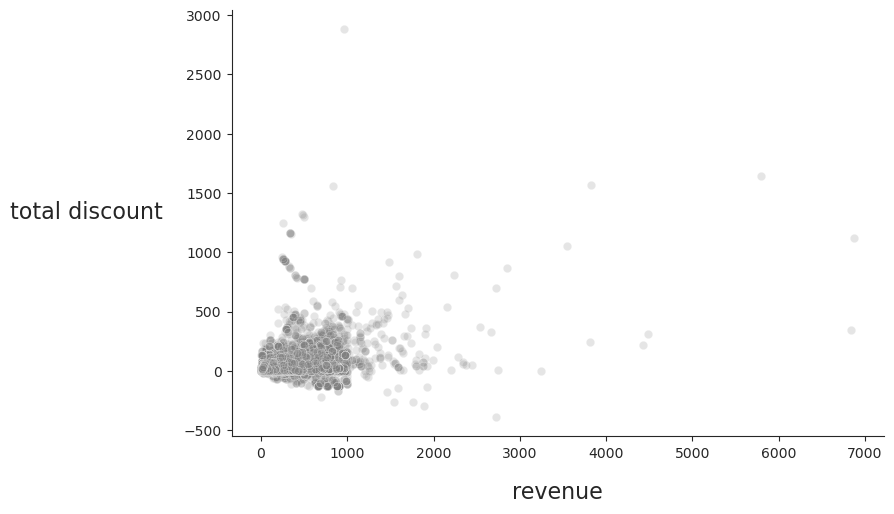

In [60]:
# Correlation between revenue and discount

# Plot
discount_rel_plot = sns.relplot(
    data=products_orderline_merge,
    x='unit_price_total',
    y='total_discount',
    color = 'grey',
    aspect=1.5,
    alpha=0.2
)

# set x labels
discount_rel_plot.ax.set_xlabel(
    "revenue",
    fontsize=16,
    labelpad=15,
)
# set y labels
discount_rel_plot.ax.set_ylabel(
    "total discount",
    fontsize=16,
    rotation=0,
    labelpad=70
)


discount_rel_plot.savefig("plots/revenue_discount_correlation.png")

Text(13.819444444444452, 0.5, 'median of\ntotal discount')

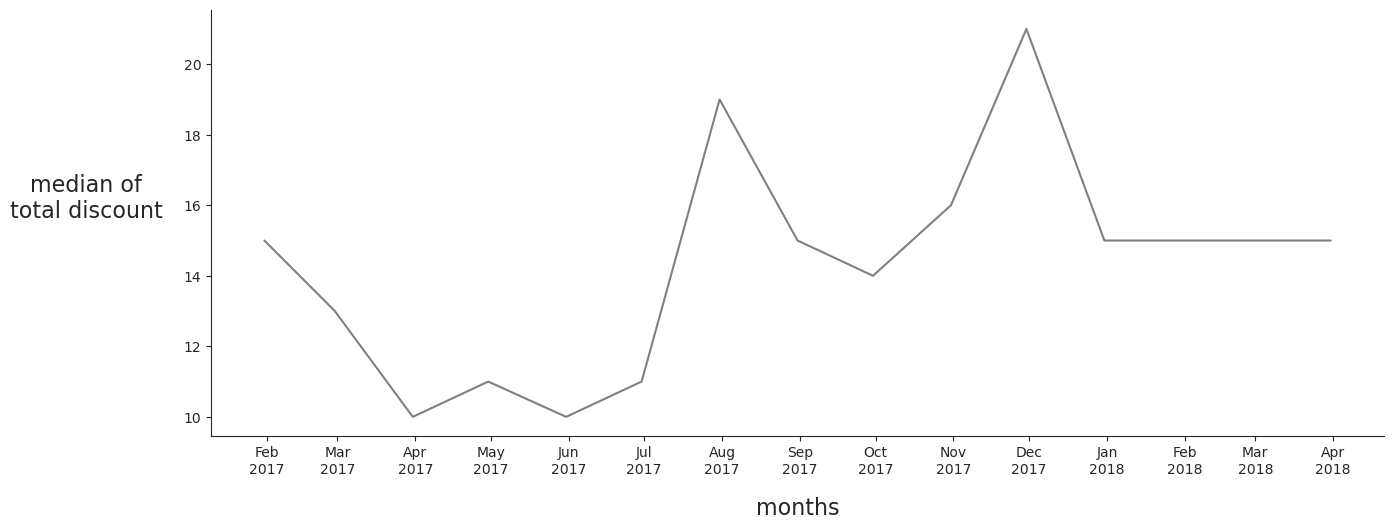

In [46]:
# total discount per month
import matplotlib.dates as mdates

total_discount_month = products_orderline_merge.resample('ME',on='date')['total_discount'].agg(['mean','median'])
total_discount_month

# Plot
discount_month_plot = sns.relplot(
    kind='line',
    data=total_discount_month,
    x='date',
    y='median',
    color = 'grey',
    aspect=2.5,
)

discount_month_plot.ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
discount_month_plot.ax.xaxis.set_major_locator(mdates.MonthLocator())


# set title
discount_month_plot.ax.set_title(
    r"",
    fontsize=18,
    y=1.05
)
# set x labels
discount_month_plot.ax.set_xlabel(
    "months",
    fontsize=16,
    labelpad=15,
)
# set y labels
discount_month_plot.ax.set_ylabel(
    "median of\ntotal discount",
    fontsize=16,
    rotation=0,
    labelpad=70
)

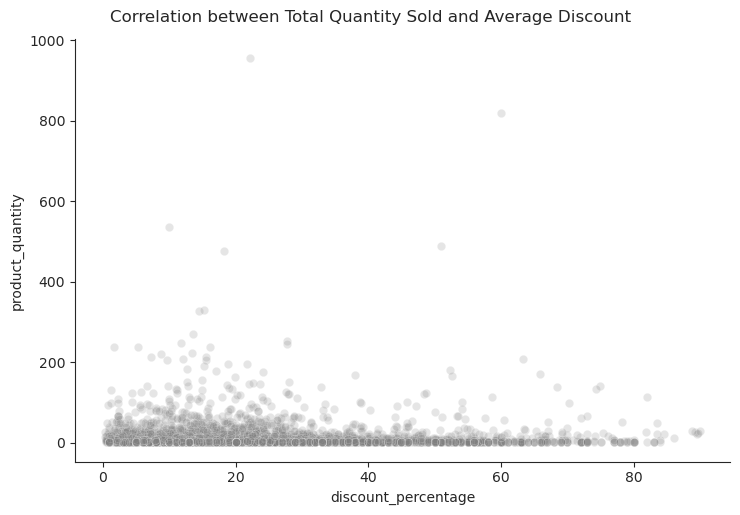

In [59]:
# Correlation between total quantity sold and average percentage discount per product

product_quantity_discount = products_orderline_merge.groupby('sku').agg({'discount_percentage':'mean', 'product_quantity':'sum'})
discount_filter = product_quantity_discount['discount_percentage'] > 0
product_quantity_discount = product_quantity_discount.loc[discount_filter]

# Plot
quantity_discount = sns.relplot(
    data=product_quantity_discount,
    x='discount_percentage',
    y='product_quantity',
    color = 'grey',
    aspect=1.5,
    alpha=0.2
)

quantity_discount.fig.suptitle(
    "Correlation between Total Quantity Sold and Average Discount",
    y=1.02
)

quantity_discount.savefig("plots/product_quantity_discount_correlation.png")


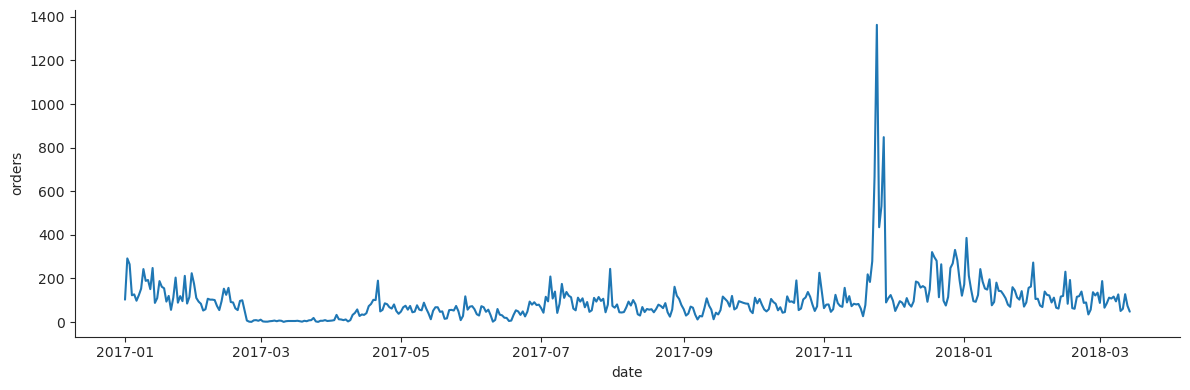

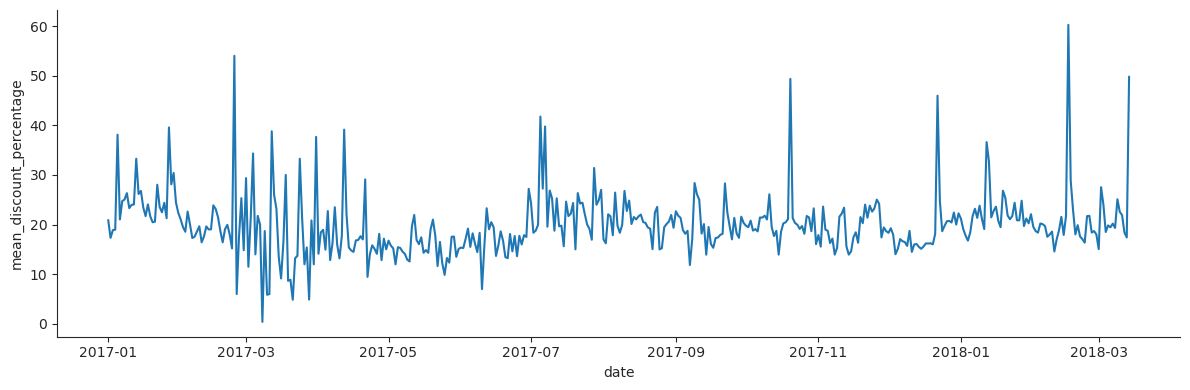

In [50]:
# average percentage discount and total number of orders daily
import matplotlib.dates as mdates

daily_orders = products_orderline_merge.resample('D',on='date').agg(orders=('id_order','nunique'))

daily_percent_discount = products_orderline_merge.resample('D',on='date').agg(mean_discount_percentage= ('discount_percentage','mean'))


# Plot
orders = sns.relplot(
    kind='line',
    data=daily_orders,
    x='date',
    y='orders',
    aspect=3,
    height=4
)

percent_discount = sns.relplot(
    kind='line',
    data=daily_percent_discount,
    x='date',
    y='mean_discount_percentage',
    aspect=3,
    height=4
)

# discount_month_plot.ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
# discount_month_plot.ax.xaxis.set_major_locator(mdates.MonthLocator())


# # set title
# discount_month_plot.ax.set_title(
#     r"",
#     fontsize=18,
#     y=1.05
# )
# # set x labels
# discount_month_plot.ax.set_xlabel(
#     "months",
#     fontsize=16,
#     labelpad=15,
# )
# # set y labels
# discount_month_plot.ax.set_ylabel(
#     "median of\ntotal discount",
#     fontsize=16,
#     rotation=0,
#     labelpad=70
# )

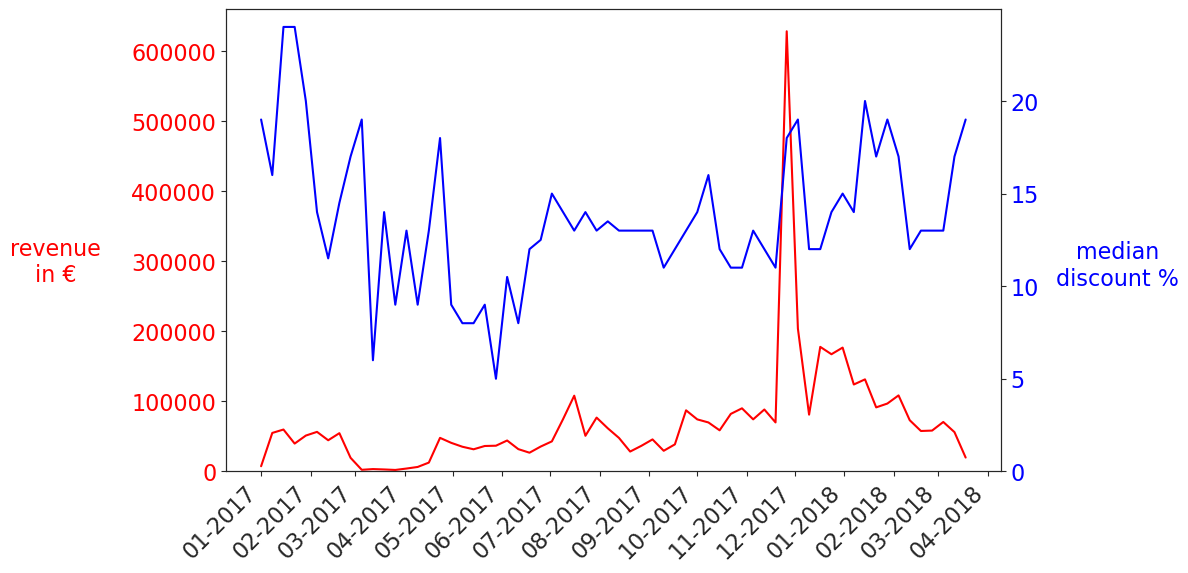

In [53]:
# product revenue over time and product discount over time for the top 250 revenue products
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

plt.rcParams["axes.grid"] = False  # explicitly disable gridlines

# top 50 revenue products 
top250_products_df = products_orderline_merge.groupby('sku').agg({'unit_price_total': 'sum'}).sort_values(by='unit_price_total',ascending=False).head(250)
top250_products_merge = products_orderline_merge.merge(top250_products_df, on='sku', how = 'inner')


weekly_revenue_top_250 = top250_products_merge.resample('W',on='date').agg(revenue=('unit_price_total_x','sum'))

weekly_discount_top_250 = top250_products_merge.resample('W',on='date').agg(mean_discount_percentage= ('discount_percentage','median'))

# create Figure and one Axes (ax1) which stand for the plotting area and is like a container that holds the data plots
fig, ax1 = plt.subplots(figsize=(10, 6))  # adjust size as needed
FONT_SIZE = 16

# plot on the primary axes
# left axis: revenue
ax1.plot(weekly_revenue_top_250.index,
         weekly_revenue_top_250["revenue"],
         color="red",
         label=r"revenue"
         )
ax1.set_ylabel("revenue\nin €", color="red", fontsize=FONT_SIZE, rotation=0)
ax1.tick_params(axis='y', labelcolor="red", labelsize=FONT_SIZE)
ax1.yaxis.set_label_coords(-0.22, 0.4)
ax1.set_ylim(bottom=0)

# x-axis: one tick per month, formatted
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%Y"))
ax1.tick_params(axis='x', labelsize=FONT_SIZE, rotation=45)
for label in ax1.get_xticklabels():
    label.set_ha('right')

# create a second y-axis that shares the same x-axis as ax1
ax2 = ax1.twinx()  # ax2 is a different Axes instance, overlaid on ax1

# plot on the secondary axes
# right axis: mean discount percentage
ax2.plot(weekly_discount_top_250.index,
         weekly_discount_top_250["mean_discount_percentage"],
         color = "blue",
         label=r"median discount %"
         )
ax2.set_ylabel("median\ndiscount %", color="blue", fontsize=FONT_SIZE, rotation=0)
ax2.tick_params(axis='y', labelcolor="blue", labelsize=FONT_SIZE)
ax2.yaxis.set_label_coords(1.15, 0.5)
ax2.set_ylim(bottom=0) 


plt.savefig("plots/weekly_revenue_discount_top_250.png", dpi=400, bbox_inches="tight", facecolor=fig.get_facecolor())

plt.show()

In [54]:
# percentage of total revenue of top 50 products
top250_products_df['unit_price_total'].sum() / products_orderline_merge['unit_price_total'].sum() *100

np.float64(56.83079490668046)